# 5주차_데이터 탐색과 시각화 Ⅱ

- 분포 시각화


---

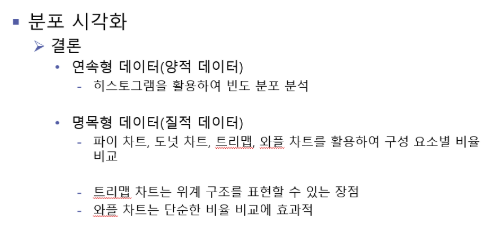

In [7]:
# 필요한 패키지 설치
# !pip install plotly
# !pip install pywaffle
# 주석 처리된 이 두 줄은 외부 패키지를 설치하는 명령어임
# - plotly: 인터랙티브한(줌, 클릭 등 가능) 시각화를 위한 고급 시각화 라이브러리
# - pywaffle: 와플 차트(Waffle Chart)를 그리기 위한 전용 라이브러리
# 주석을 제거하고 실행하면 필요한 경우 자동으로 설치됨 (단, Jupyter Notebook 환경에서만 사용 가능)

import matplotlib.pyplot as plt
# matplotlib의 기본 시각화 도구인 pyplot을 불러옴
# 정적 이미지 기반의 라인 그래프, 바 차트, 히스토그램 등을 생성할 수 있음

import pandas as pd
# 데이터 처리 및 분석을 위한 표 형식(DataFrame)의 데이터프레임 라이브러리

import seaborn as sns
# 통계 기반의 시각화를 지원하는 matplotlib 기반의 시각화 라이브러리
# 색상 스타일, grid, 분포 시각화 등에 강점을 가짐

import numpy as np
# 수치 계산, 배열 처리, 통계 함수 등을 제공하는 핵심 수치 연산 라이브러리

import plotly.express as px
# plotly의 고수준 시각화 API로, 인터랙티브 그래프를 간단한 코드로 생성할 수 있음
# 예: 트리맵, 버블 차트, 선 그래프 등을 마우스로 확대/축소/툴팁 기능과 함께 생성 가능

from pywaffle import Waffle
# pywaffle은 matplotlib 기반에서 와플 차트(비율을 격자로 표현하는 도식)를 쉽게 생성하는 클래스임
# FigureClass=Waffle로 설정하면 일반 플롯처럼 와플 차트를 사용할 수 있음

plt.rcParams['figure.dpi'] = 300
# matplotlib 전체 그래프 출력 시의 해상도를 300DPI(Dots Per Inch)로 설정함
# 인쇄 품질, 발표용 슬라이드 등에 적합하도록 고해상도 출력 보장


In [8]:
# 데이터 불러오기
# https://www.kaggle.com/datasets/sewonghwang/six-countries-height-samples
df = pd.read_csv("../../main/datasets/six_countries_height_samples.csv")

# 데이터 샘플 확인
df.head()

,id,country,sex,height_cm
0,rhop00001,AUSTRALIA,man,189
1,rhop00002,AUSTRALIA,man,165
2,rhop00003,AUSTRALIA,man,189
3,rhop00004,AUSTRALIA,man,164
4,rhop00005,AUSTRALIA,man,192


In [9]:
df.shape

(1068, 4)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         1068 non-null   object
 1   country    1068 non-null   object
 2   sex        1068 non-null   object
 3   height_cm  1068 non-null   int64 
dtypes: int64(1), object(3)
memory usage: 33.5+ KB


In [11]:
# NaN, 결측치 개수
df.isnull().sum()

id           0
country      0
sex          0
height_cm    0
dtype: int64

In [12]:
df.describe()

,height_cm
count,1068.000000
mean,171.530899
std,7.839055
min,152.000000
25%,166.000000
50%,171.000000
75%,177.000000
max,194.000000


### 📌 왜도(Skewness) & 첨도(Kurtosis) 핵심 요약표

| 분포 유형 | 왜도 | 첨도 | 중심 모양 | 꼬리의 두께 | 극단값 빈도 | 실제 예시 |
| --- | --- | --- | --- | --- | --- | --- |
| **정규 분포** | 0 | 0 | 적절한 종 모양 | 보통 두께 | 보통 | 키, IQ, 자연계 수치 등 |
| **양의 왜도** | > 0 | 보통 또는 ↑ | 왼쪽에 치우침 | 오른쪽 꼬리 두꺼움 | 큰 값 쪽 극단값 많음 | 소득, 부동산 가격, 대기오염 수치 |
| **음의 왜도** | < 0 | 보통 또는 ↑ | 오른쪽에 치우침 | 왼쪽 꼬리 두꺼움 | 작은 값 쪽 극단값 많음 | 대부분 고득점 + 소수 저득점 시험 점수 |
| **높은 첨도** | ≈ 0 또는 ± | **≫ 0** | 매우 뾰족하고 집중 | **꼬리 매우 두꺼움** | 극단값 **매우 자주 발생** | 금융 자산 수익률, 사고 빈도 등 리스크 관련 |
| **낮은 첨도** | ≈ 0 또는 ± | **< 0** | 평평하고 분산됨 | 꼬리 매우 얇음 | 극단값 거의 없음 | 균등 분포, 예: 주사위, 랜덤 샘플링 등 |

### ✅ 왜도(Skewness) 및 첨도(Kurtosis) 결과 해석 기준 (pandas 기준)

| 항목 | pandas 함수 | 값의 이론적 범위 | 실무 해석 범위 | 해석 기준 (정상/비정상) |
| --- | --- | --- | --- | --- |
| **왜도** | `DataFrame.skew()` | -∞ ~ +∞ | –3 ~ +3 주로 발생 | `–1 ~ +1`: 정상 (대칭 또는 약간 치우침)  `<-1 또는 >+1`: 비정상 (심한 치우침) |
| **첨도** | `DataFrame.kurt()` | -∞ ~ +∞ (초과 첨도) | –2 ~ +5 주로 발생 | `–1 ~ +1`: 정상 (정규분포 유사)  `<–1`: 너무 평평 (극단값 부족)  `>+1`: 뾰족하고 극단값 많음 |

---

### 📌 실무 해석 기준 요약 표 (사용자 코드 기준)

| 지표 | 값 해석 기준 | 설명 |
| --- | --- | --- |
| 왜도 ∈ [–1, +1] | ✅ 정상 분포 | 거의 대칭 또는 약간 치우침 |
| 왜도 < –1 또는 > +1 | ⚠️ 비정상 분포 | 한쪽으로 강하게 치우쳐 있음 (좌우 꼬리 비대칭) |
| 첨도 ∈ [–1, +1] | ✅ 정상 분포 | 정규분포와 유사, 꼬리의 두께도 보통 |
| 첨도 < –1 | ⚠️ 너무 평평함 | 극단값(꼬리) 거의 없음, 데이터가 분산되어 있음 |
| 첨도 > +1 | ⚠️ 너무 뾰족함 | 중심에 데이터 몰려 있고 극단값 존재 (이상치 민감한 분포 가능성) |

### 📌 꼬리란?

- 분포 곡선을 그렸을 때, **평균(중앙값)으로부터 멀리 떨어진 좌우 끝 부분**을 "꼬리(Tail)"라고 부릅니다.
- 보통 **좌측 꼬리**는 매우 작은 값, **우측 꼬리**는 매우 큰 값이 위치하는 영역입니다.

---

### ✅ "꼬리가 길다"는 의미

| 구분 | 설명 |
| --- | --- |
| **길다** | **평균에서 멀리 떨어진 위치까지 데이터가 퍼져 있음** (즉, 값의 범위가 넓음) |
| **짧다** | **극단적인 값까지 도달하는 범위가 좁음** (즉, 값이 평균 근처에 집중되어 있음) |

즉, 꼬리가 길다는 건:

- **평균에서 매우 멀리 떨어진 극단적인 값이 존재할 수 있는 범위가 크다**
- 그래프에서 꼬리 부분의 곡선이 **천천히 0에 수렴하며, 멀리까지 이어진다**
- → **값의 분포 범위(Range)가 넓고**, 이상치가 발생할 **가능성**이 존재한다
- → 반드시 **극단값이 많다는 뜻은 아님** (빈도는 별개)

---

### ✅ "꼬리가 두껍다"는 의미

| 구분 | 설명 |
| --- | --- |
| **두껍다** | 그 구간(꼬리)에 **상대적으로 많은 데이터**가 존재함 |
| **얇다** | 그 구간에 데이터가 **거의 없음** (즉, 극단값이 드묾) |

즉, 꼬리가 두껍다는 건:

- **평균에서 멀리 떨어진 값들(극단값, 이상치)이 자주 나온다**
- 그래프에서 꼬리 부분의 곡선이 **낮고 완만하게 멀리까지 이어진다**
- → **분산이 커질 수 있으며**, 예측 모델링 시 **리스크(불확실성)가 크다**

---

### 🔍 시각적 예시로 이해하기

| 첨도 종류 | 분포 모양 설명 | 꼬리 | 의미 |
| --- | --- | --- | --- |
| **정규분포 (첨도 ≈ 0)** | 가운데는 뾰족, 양쪽 꼬리는 적절히 가늘게 줄어듦 | 보통 | 극단값 적절한 수준 |
| **높은 첨도 (첨도 > 0)** | 중심은 더 뾰족하고, 꼬리는 멀리까지 천천히 줄어듦 | **두꺼움** | 극단값이 자주 발생 |
| **낮은 첨도 (첨도 < 0)** | 중심이 평평하고, 꼬리도 빨리 줄어듦 | 얇음 | 극단값 거의 없음 |

In [13]:
# ▶️ 숫자형 데이터의 왜도(Skewness)를 계산함
# - 왜도는 데이터 분포의 비대칭성을 나타내는 통계량임
# - 분포가 평균을 기준으로 어느 쪽으로 더 퍼져 있는지(치우쳐 있는지)를 수치로 표현함

df.select_dtypes(include=['number']).skew()

# ───────────────────────────────────────────────────────
# 📌 [왜도(Skewness)의 의미 및 해석]

# ✅ 왜도란?
# - 데이터 분포의 **꼬리(Tail)** 방향과 길이를 수치화한 것임
# - 여기서 '꼬리'란, **분포에서 평균으로부터 멀리 떨어져 있는 극단적인 값들(극단치)**이 존재하는 방향을 의미함
#   예: 100명의 키 데이터 중 대부분이 160~180cm인데 220cm가 1명 있는 경우 → 이 220이 '꼬리'

# ✅ 왜도가 0인 경우:
# - 분포가 완벽하게 좌우 대칭인 경우
# - 즉, 평균을 중심으로 데이터가 고르게 분포된 정규분포 형태

# ✅ 양의 왜도 (왜도 > 0):
# - **오른쪽 꼬리가 길다**는 의미
# - 오른쪽으로 평균보다 훨씬 큰 값들이 존재함
# - 대부분의 데이터는 왼쪽(작은 값)에 몰려 있고, 소수의 매우 큰 값이 평균을 끌어올리는 형태
# - 예시: 소득 분포 (대부분 적은 소득, 일부 매우 높은 소득)

# ✅ 음의 왜도 (왜도 < 0):
# - **왼쪽 꼬리가 길다**는 의미
# - 평균보다 훨씬 작은 값들이 존재함
# - 대부분의 데이터는 오른쪽(큰 값)에 몰려 있고, 소수의 매우 작은 값이 평균을 끌어내리는 형태
# - 예시: 시험 점수에서 대부분이 높은 점수, 소수만 낮은 점수일 경우

# 📈 시각적으로 보면:
# - 양의 왜도: 왼쪽이 봉우리, 오른쪽으로 천천히 낮아지는 그래프
# - 음의 왜도: 오른쪽이 봉우리, 왼쪽으로 천천히 낮아지는 그래프

# 🎯 실무에서는 왜도를 통해 데이터 정규성 여부 판단 및 로그 변환(log-transform) 등의 전처리 여부를 판단함

height_cm    0.347757
dtype: float64

In [14]:
# ▶️ 숫자형 데이터의 첨도(Kurtosis)를 계산함
# - 첨도는 데이터 분포의 **뾰족한 정도**와 **꼬리(극단값)의 두께**를 나타내는 통계량임
# - 특히, 평균 주변으로 데이터가 얼마나 집중되어 있고,
#   평균에서 멀리 떨어진 극단적인 값들이 얼마나 자주 나타나는지를 보여줌

df.select_dtypes(include=['number']).kurt()

# ──────────────────────────────────────────────────────────────
# 📌 [첨도(Kurtosis)의 의미 및 해석]

# ✅ 첨도란?
# - 분포의 '뾰족함'과 '꼬리의 두꺼움'을 측정하는 통계량
# - 특히 평균을 중심으로 값이 얼마나 몰려 있는지(중심 집중도)와
#   평균에서 멀리 떨어진 극단적인 값(꼬리 영역)이 얼마나 자주 나타나는지를 함께 반영함

# ✅ 꼬리(Tail)의 의미:
# - 평균에서 많이 떨어진 극단적인 데이터(극단치)의 분포
# - 예: 대부분의 값이 50~60 사이에 있는데, 몇 개의 값이 100이나 0에 존재하는 경우 → 그 100, 0이 꼬리

# ✅ pandas의 kurt() 함수는 '초과 첨도 (Excess Kurtosis)'를 반환함
# - 초과 첨도는 기준값인 3(정규분포의 첨도)에서 3을 뺀 값으로 해석됨
# - 즉, `0`은 정규분포와 동일, `> 0`은 뾰족, ` < 0`은 평평하다고 봄

# ──────────────────────────────────────────────────────────────
# 📊 kurt() 결과 해석표

# kurt() 값      실제 의미                                 예시
# -----------   -----------------------------------------  ------------------------------
# = 0           정규분포와 유사한 뾰족함                   평균 중심으로 적절히 퍼짐
# > 0           첨도가 높은 분포 (Leptokurtic)           중심이 뾰족하고 꼬리가 두꺼움 → 극단값이 자주 발생
# < 0           첨도가 낮은 분포 (Platykurtic)          중심이 평평하고 꼬리가 얇음 → 극단값이 거의 없음

# ✅ 실무 예시
# - 첨도 ↑: 금융 데이터처럼 갑작스러운 큰 변화(리스크)를 자주 겪는 데이터
# - 첨도 ↓: 자연적으로 제한된 범위에서만 발생하는 데이터 (예: 키, 체온 등)

# 📌 시각적으로 보면:
# - 첨도 ↑ : 높은 봉우리 + 두꺼운 꼬리 (중심값 많고 극단값도 많음)
# - 첨도 ↓ : 평평한 봉우리 + 얇은 꼬리 (극단값 거의 없음)

# 🎯 첨도는 데이터의 안정성이나 극단값 처리 여부(log-transform 등)를 판단할 때 중요한 지표가 됨


height_cm   -0.096823
dtype: float64

In [15]:
# 공분산 행렬
df.select_dtypes(include=['number']).cov()
# 데이터프레임(df)에서 수치형(numeric) 데이터 컬럼만 선택하여 공분산 행렬을 계산함
# 공분산은 두 수치 변수 간의 선형 관계 방향과 크기를 나타내는 지표임
# - 공분산 > 0: 한 변수가 증가할 때 다른 변수도 증가하는 경향 (같은 방향)
# - 공분산 < 0: 한 변수가 증가할 때 다른 변수는 감소하는 경향 (반대 방향)
# - 공분산 ≈ 0: 두 변수 간 선형 관계가 거의 없음
# 공분산은 단위(스케일)에 영향을 많이 받기 때문에 값의 절대 크기로 비교하기보다는 양수/음수 여부나 방향성 해석에 활용됨
# 일반적으로는 상관계수 행렬(corr())과 함께 사용하여 관계의 강도까지 판단하는 것이 더 적절함


,height_cm
height_cm,61.450778


In [16]:
# 상관계수 행렬
df.select_dtypes(include=['number']).corr()
# 데이터프레임(df)에서 수치형(numeric) 컬럼만 선택한 후, 
# 이들 간의 피어슨 상관계수(Pearson Correlation Coefficient)를 계산함
# 상관계수는 두 변수 간의 선형적 관계의 방향과 강도를 [-1, 1] 사이의 값으로 표현함

# 📌 상관계수 해석 기준:
# - 1.0: 완전한 양의 선형 상관관계 (두 변수 모두 동시에 증가)
# - 0.0: 선형 상관 없음 (비선형 관계일 수는 있음)
# - -1.0: 완전한 음의 선형 상관관계 (한 변수 증가 시 다른 변수는 감소)

# pandas의 기본 corr() 함수는 method='pearson'이 기본값임
# 즉, 공분산을 각 변수의 표준편차로 나눈 정규화된 지표를 의미함 (단위의 영향 없음 → 비교 가능성 높음)

# 이 결과는 변수 간의 관련성 탐색, 다중공선성 확인, PCA 등 차원 축소 전처리, 변수 선택 등에 활용됨


,height_cm
height_cm,1.0


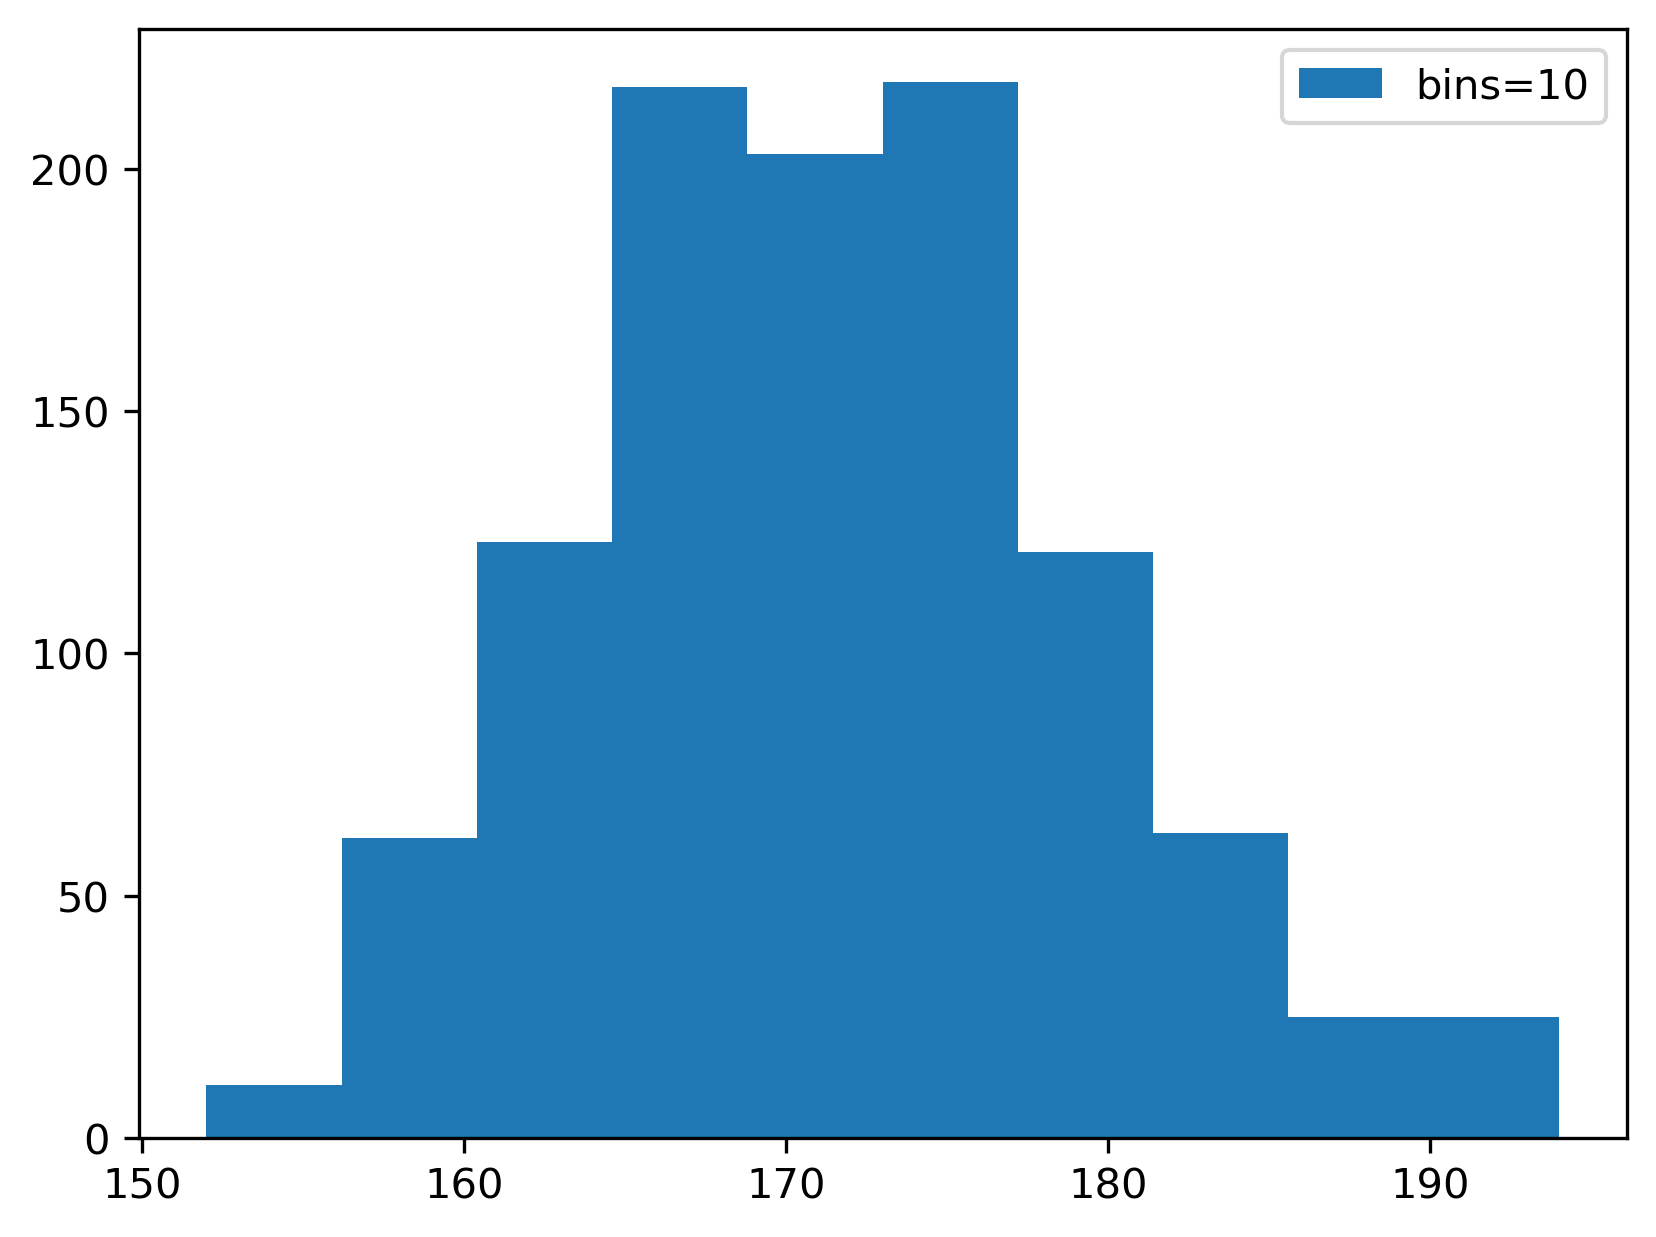

In [18]:
# 신장 컬럼만 필터링
df1 = df[['height_cm']]
# 전체 데이터프레임에서 키(height_cm) 컬럼만 추출하여 별도 데이터프레임 df1에 저장함
# 단변량 분포 시각화를 위해 불필요한 열은 제거하고 키만 남김

# 10개의 구간으로 히스토그램 시각화
plt.hist(df1, bins=10, label='bins=10')
# df1의 키 데이터를 최솟값~최댓값 범위 내에서 10개의 동일 간격 구간(bin)으로 나눠 히스토그램 생성
# 각 구간의 실제 너비는 데이터 범위에 따라 자동으로 계산되며, 약 10cm로 고정되는 것은 아님
# 각 막대의 높이는 해당 구간에 포함된 데이터 수(빈도)를 의미함

plt.legend()
# 범례 표시 – label에서 지정한 'bins=10'이 여기에 사용됨

plt.show()
# 완성된 히스토그램 그래프 출력

### ✅ 코드 비교

```python
df1 = df[['height_cm']]

```

- **결과 타입**: `pandas.DataFrame`
- **형태**: 열이 하나인 *2차원 테이블*
- **열 이름 유지됨**
- ✅ 열 여러 개를 리스트로 지정할 수 있음: `df[['height_cm', 'weight_kg']]`

---

```python
df1 = df['height_cm']

```

- **결과 타입**: `pandas.Series`
- **형태**: 열 하나짜리 *1차원 벡터*
- ❌ 여러 열을 선택할 수 없음 (한 열만 가능)

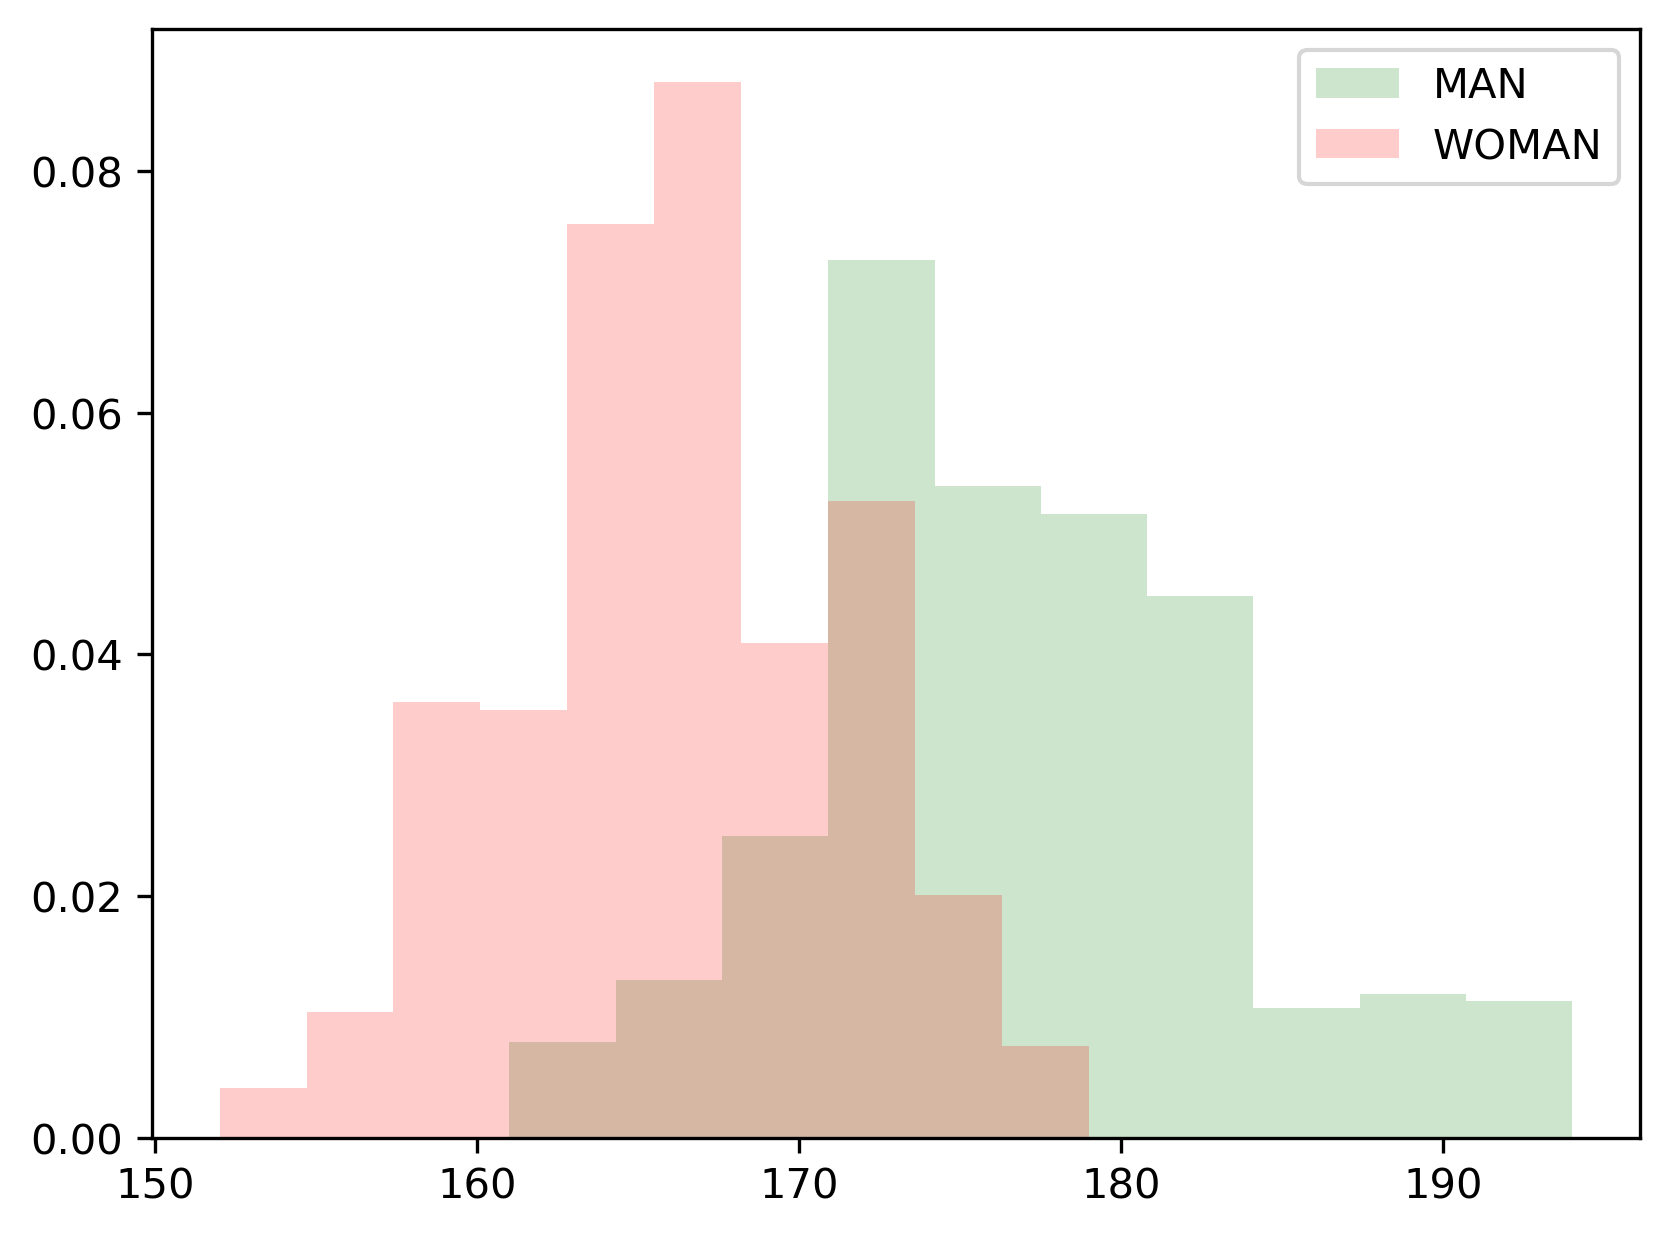

In [19]:
# 남성 여성 별도 데이터셋 생성
df1_1 = df[df['sex'].isin(['man'])]
# 원본 데이터프레임(df)에서 'sex' 컬럼이 'man'인 행만 필터링하여 df1_1에 저장함
# isin(['man'])은 리스트로 조건을 주기 때문에 확장성 있는 필터링 방식임 (예: 여러 성별 포함 가능)

df1_1 = df1_1[['height_cm']]
# df1_1에서 키(height_cm) 컬럼만 선택하여 단일 컬럼 데이터프레임으로 재구성함
# 히스토그램에서 키 분포만 분석할 것이므로 다른 정보는 제거함

df1_2 = df[df['sex'].isin(['woman'])]
# 성별이 'woman'인 행만 필터링하여 여성 데이터셋(df1_2) 생성함

df1_2 = df1_2[['height_cm']]
# 여성 데이터셋에서도 키 컬럼만 추출함

# 10cm 단위로 남성, 여성 신장 히스토그램 시각화
plt.hist(df1_1, color='green', alpha=0.2, bins=10, label='MAN', density=True)
# 남성 키 데이터를 히스토그램으로 시각화함
# - color='green': 히스토그램을 녹색으로 표현함
# - alpha=0.2: 투명도를 20%로 설정하여 여성 데이터와 겹쳐도 시각적으로 구분 가능하게 함
# - bins=10: 10개 구간(bin)으로 나눠 시각화함 (대략 10cm 단위)
# - label='MAN': 범례에 표시될 이름 지정
# - density=True: 각 구간의 빈도를 정규화하여 전체 면적이 1이 되도록 함 → 남녀 분포를 동일한 기준으로 비교 가능

plt.hist(df1_2, color='red', alpha=0.2, bins=10, label='WOMAN', density=True)
# 여성 키 데이터를 빨간색 히스토그램으로 시각화함 (동일한 파라미터 설정으로 비교 가능하게 처리)

plt.legend()
# 범례 추가: 남성과 여성의 색상 및 레이블이 그래프에 표시됨

plt.show()
# 남성과 여성의 히스토그램이 하나의 플롯에 함께 출력됨
# → 성별 간 키 분포 차이를 직관적으로 비교할 수 있음

In [22]:
# 파이차트, 도넛차트 시각화를 위한 데이터 전처리

df2 = df[['country', 'height_cm']]
# 전체 원본 데이터프레임(df)에서 시각화에 필요한 두 컬럼만 선택함
# 'country': 국가명 (범주형 변수)
# 'height_cm': 키 정보 (수치형 변수)

# 키 175 이상만 추출
df2 = df2[df.height_cm >= 175]
# height_cm 값이 175 이상인 행만 필터링함
# df.height_cm >= 175는 pandas의 Boolean 연산
# Boolean Series는 행 필터링 시 마스크(mask) 역할
# → 175cm 이상인 사람의 국가별 분포를 시각화하려는 목적
# 이 조건은 '상대적으로 키가 큰 사람들'에 대한 국가별 분포를 분석하기 위한 기준임

df2 = df2.groupby('country').count().reset_index()
# 국가별로 그룹화한 뒤, 각 그룹에 속한 행(= 175cm 이상인 사람 수)을 count()로 계산함
# 여기서는 height_cm 컬럼을 대상으로 count하지만, 실제로는 행 수를 세는 것과 동일함
# reset_index()는 groupby의 결과로 생성된 인덱스를 일반 컬럼으로 다시 되돌리는 처리임

df2 = df2.rename(columns={'height_cm': 'height_cm_count'})
# 시각화를 위한 의미 있는 컬럼명으로 변경
# 'height_cm' → 'height_cm_count'로 이름을 바꿔, 이 컬럼이 실제 '개수(count)'임을 명확하게 표시함
# 이 컬럼을 파이차트/도넛차트에서 비율 계산 기준으로 사용함

df2.head(10)
# 전처리 결과 확인
# 각 국가(country)별로 175cm 이상인 사람의 수(height_cm_count)가 계산된 형태임
# 이 데이터를 통해 각 국가가 전체에서 차지하는 비율을 파이/도넛 차트로 시각화할 수 있음


,country,height_cm_count
0,AUSTRALIA,68
1,DENMARK,59
2,ITALY,67
3,JAPAN,46
4,KOREA,52
5,TURKEY,61


### `.reset_index()` 안 하면?

### 예시:

```python
df2 = df2.groupby('country').count()
print(df2.head())
```

출력 형태는 다음과 같음:

```
         height_cm
country
Brazil          58
Japan           62
Korea           53
USA             64
```

- 이 경우 **`country`는 인덱스**가 되며,
- `df2.columns`는 `['height_cm']` 하나뿐.
- `df2.index`는 국가명이 됨.

➡ **문제점:**

- 이후 `.plot()`, `.pie()`, `.bar()` 등 시각화나 병합(join/merge) 시 **country가 인덱스라서 자동 인식이 안 되거나, 추가 처리가 필요**하게 됨.

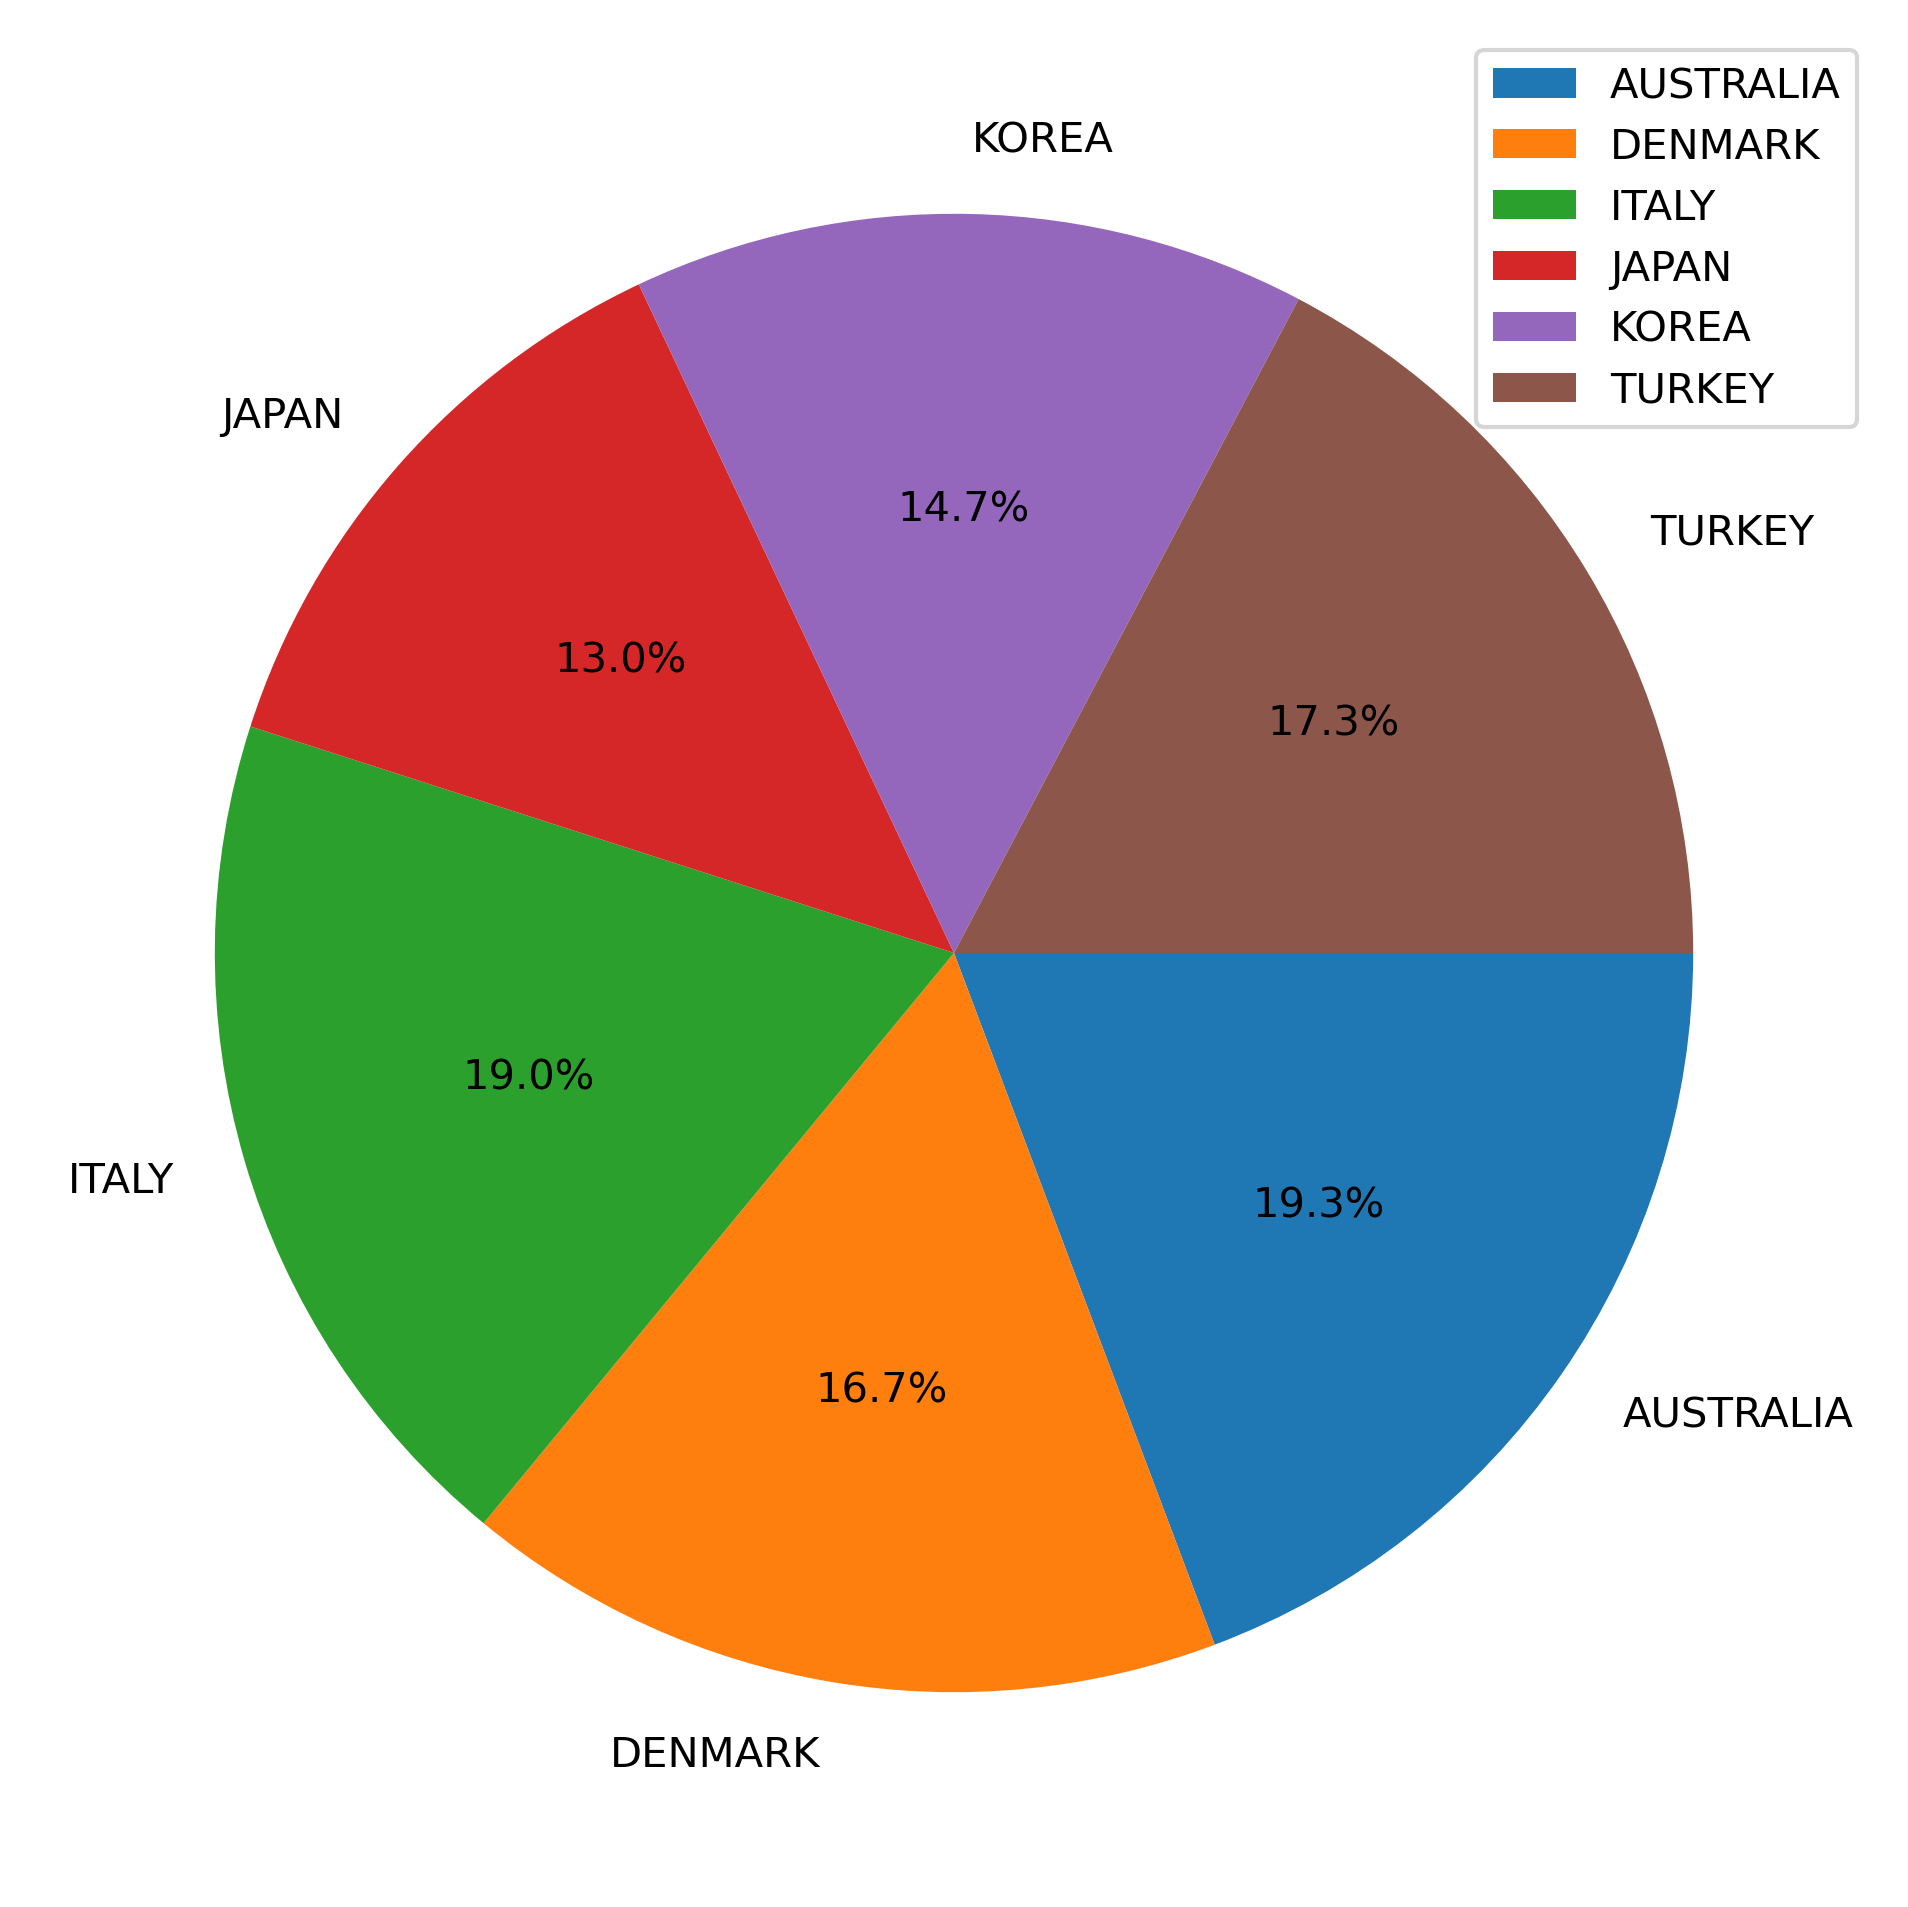

In [23]:
# 파이차트 시각화

fig = plt.figure(figsize=(8,8))  # 캔버스 생성
# 전체 그래프를 그릴 figure(도화지)를 생성함
# figsize=(8,8)로 정사각형 비율을 설정하여 원형 파이차트가 왜곡 없이 출력되도록 만듦

fig.set_facecolor('white')  # 캔버스 배경색 설정
# figure 배경색을 흰색으로 지정함 (기본값은 투명이나, 프레젠테이션 및 보고서에 적합하게 설정함)

ax = fig.add_subplot()  # 프레임 생성
# figure 안에 subplot(축, axes)을 하나 추가함
# 단일 차트이므로 인덱스 없이 단일 subplot을 생성함

# 파이차트 출력
ax.pie(
    df2.height_cm_count,  # 파이 조각의 크기 값
    labels=df2.country,   # 각 조각에 대응되는 국가명을 라벨로 설정함
    startangle=0,         # 파이차트가 시작되는 각도를 0도로 설정함 (기본은 0도 = 오른쪽 방향)
    counterclock=False,   # 시계방향으로 조각을 배치함 (기본은 반시계방향)
    autopct=lambda p : '{:.1f}%'.format(p)  
    # 각 조각의 비율을 소수점 첫째 자리까지 표시함
    # lambda p: 전달된 백분율 값(p)을 문자열 형식으로 변환하여 그래프에 출력함
)

plt.legend()  # 범례 표시
# 각 색상이 어떤 국가에 해당하는지를 별도로 설명하는 범례 박스를 추가함

plt.show()
# 구성된 파이차트를 화면에 출력함



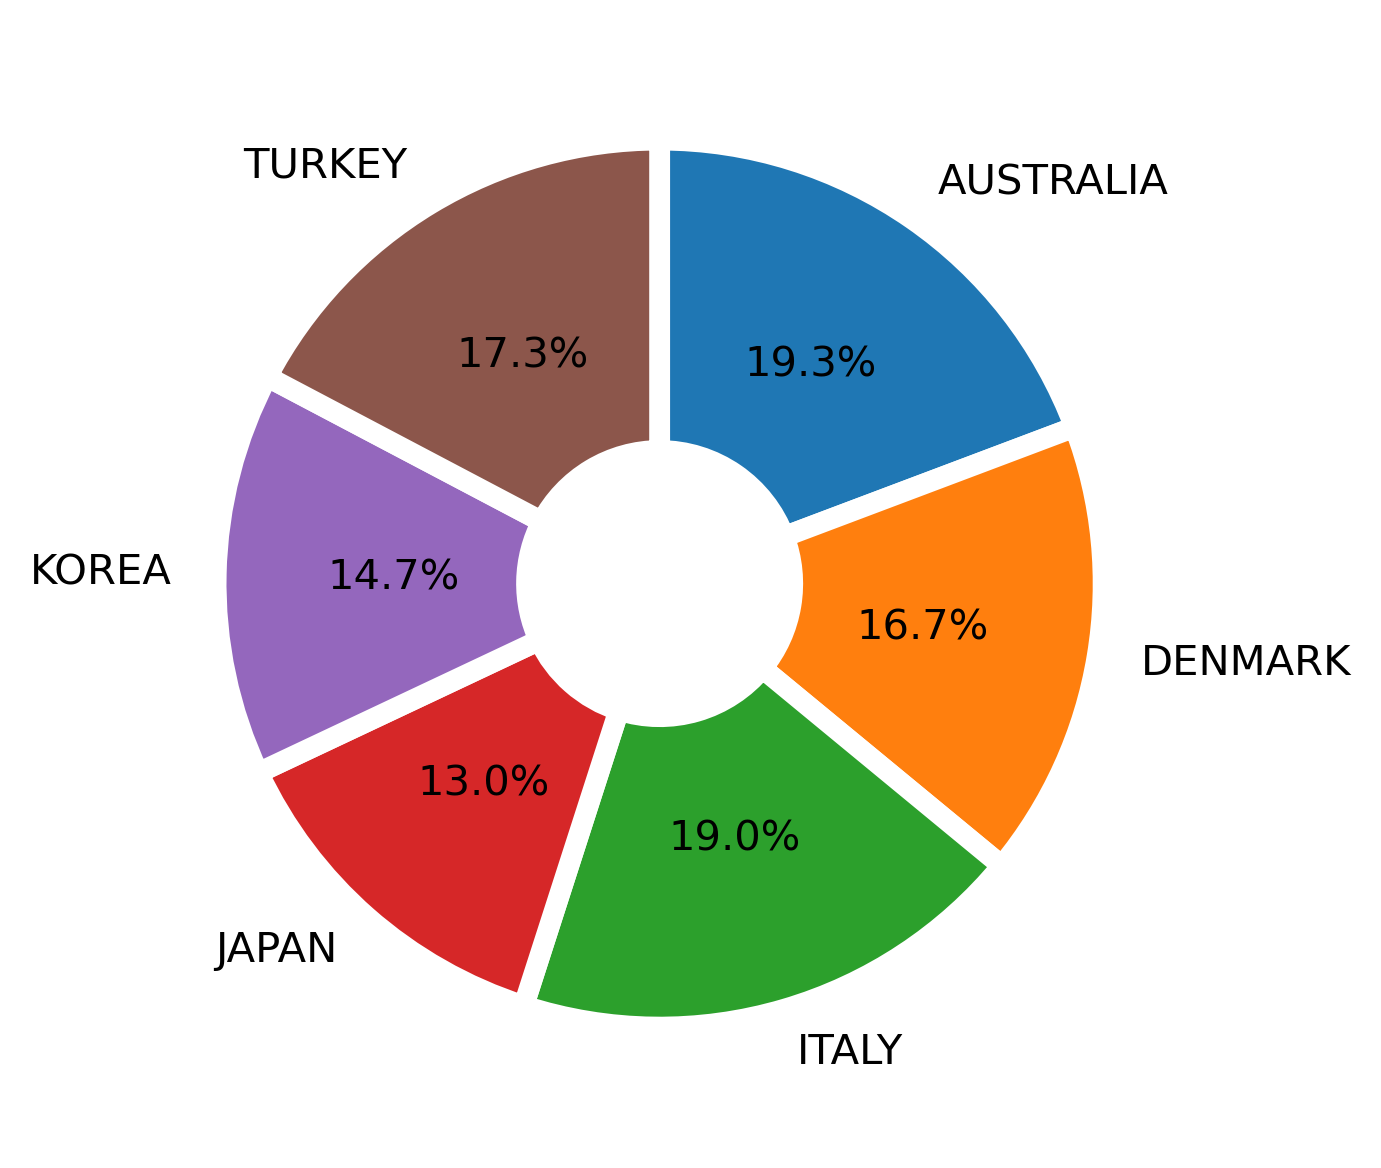

In [29]:
# 도넛차트 시각화

# 차트 형태 옵션 설정
wedgeprops = {'width': 0.7, 'edgecolor': 'w', 'linewidth': 5}
# 파이차트를 도넛 형태로 변형하기 위한 시각적 속성을 지정함
# - width: 조각의 두께를 0.7로 설정하여 중심이 뚫린 도넛 형태를 만듦 (0이면 원, 1이면 꽉 찬 파이)
# - edgecolor='w': 각 조각 경계를 흰색으로 설정하여 조각 간 구분을 명확히 함
# - linewidth=5: 경계선 두께를 5로 설정하여 시각적으로 구분이 뚜렷해지도록 함


plt.pie(
    df2.height_cm_count,       # 각 조각의 크기를 나타내는 값 (175cm 이상인 인원 수)
    labels=df2.country,        # 각 조각에 해당하는 국가명 라벨
    autopct='%.1f%%',          # 각 조각의 백분율을 소수점 첫째 자리까지 표시
    startangle=90,             # 그래프 시작 각도를 90도로 설정하여 12시 방향부터 시작되도록 함
    counterclock=False,        # 조각을 시계방향으로 배치함
    wedgeprops=wedgeprops      # 앞서 정의한 wedge 속성 적용 → 도넛 형태로 표현됨
)

plt.show()
# 도넛 차트를 최종 출력함
# 국가별로 175cm 이상인 인원 수의 비율을 시각적으로 비교 가능하게 함

In [30]:
# 트리맵 차트용 데이터셋 전처리

df3 = df[['country', 'sex', 'height_cm']]
# 원본 데이터프레임(df)에서 트리맵에 필요한 세 컬럼만 추출함
# - country: 국가명
# - sex: 성별 (man/woman)
# - height_cm: 키 (분석 대상 값)
# 트리맵은 계층적 그룹화 시각화에 쓰이므로 그룹 구분이 되는 컬럼들을 선택하는 것이 핵심임

df3 = df3[df.height_cm >= 175]
# 키가 175cm 이상인 행만 필터링함
# → 분석 목적은 '키가 큰 사람들의 분포를 국가와 성별 기준으로 파악'하는 것
# 이후 count를 수행할 예정이므로 조건을 먼저 걸어두는 것이 효율적임

# 국가, 성별 단위 신장 175cm 이상 카운팅
df3 = df3.groupby(['country', 'sex']).count().reset_index()
# 'country'와 'sex' 조합별로 그룹화한 후, 해당 그룹에 속하는 행 수를 계산함
# count()는 기본적으로 모든 수치형 컬럼에 적용되지만, 여기선 height_cm만 존재함 → 그 컬럼의 개수를 세는 효과
# reset_index()는 그룹화 결과를 일반적인 데이터프레임 형태로 되돌려줌

df3 = df3.rename(columns={"height_cm": "height_cm_count"})
# count 결과로 남은 height_cm 컬럼명을 'height_cm_count'로 변경함
# → 트리맵의 value 인자로 넣기 위해 의미 명확한 이름으로 바꿔줌


df3.head(10)

,country,sex,height_cm_count
0,AUSTRALIA,man,59
1,AUSTRALIA,woman,9
2,DENMARK,man,53
3,DENMARK,woman,6
4,ITALY,man,60
5,ITALY,woman,7
6,JAPAN,man,45
7,JAPAN,woman,1
8,KOREA,man,50
9,KOREA,woman,2


In [31]:
# 트리맵 차트 시각화

fig = px.treemap(
    df3,                             # 시각화에 사용할 전처리된 데이터프레임
    path=['sex','country'],          # 계층 구조 설정: 최상위는 'sex', 하위는 'country'
                                     # 즉, 먼저 성별로 나뉘고 그 안에서 국가별로 분할된 사각형을 생성함
    values='height_cm_count',        # 각 사각형 면적의 크기를 결정하는 기준 값
                                     # → 각 국가·성별 그룹에서 키 175cm 이상 인원의 수
    color='height_cm_count',         # 면적의 색상도 같은 값으로 지정하여 시각적 강도를 이중 표현함
                                     # 색이 진할수록 더 많은 인원 수를 의미함
    color_continuous_scale='viridis' # 색상 스케일을 'viridis'(밝은 노랑~짙은 보라)로 설정
                                     # 연속된 수치값을 부드럽게 색상으로 표현함 (높은 값 → 진한 색)
)

fig.show()
# 위에서 설정한 트리맵(fig)을 출력함 (Plotly는 인터랙티브: 마우스 오버, 줌 등 가능)


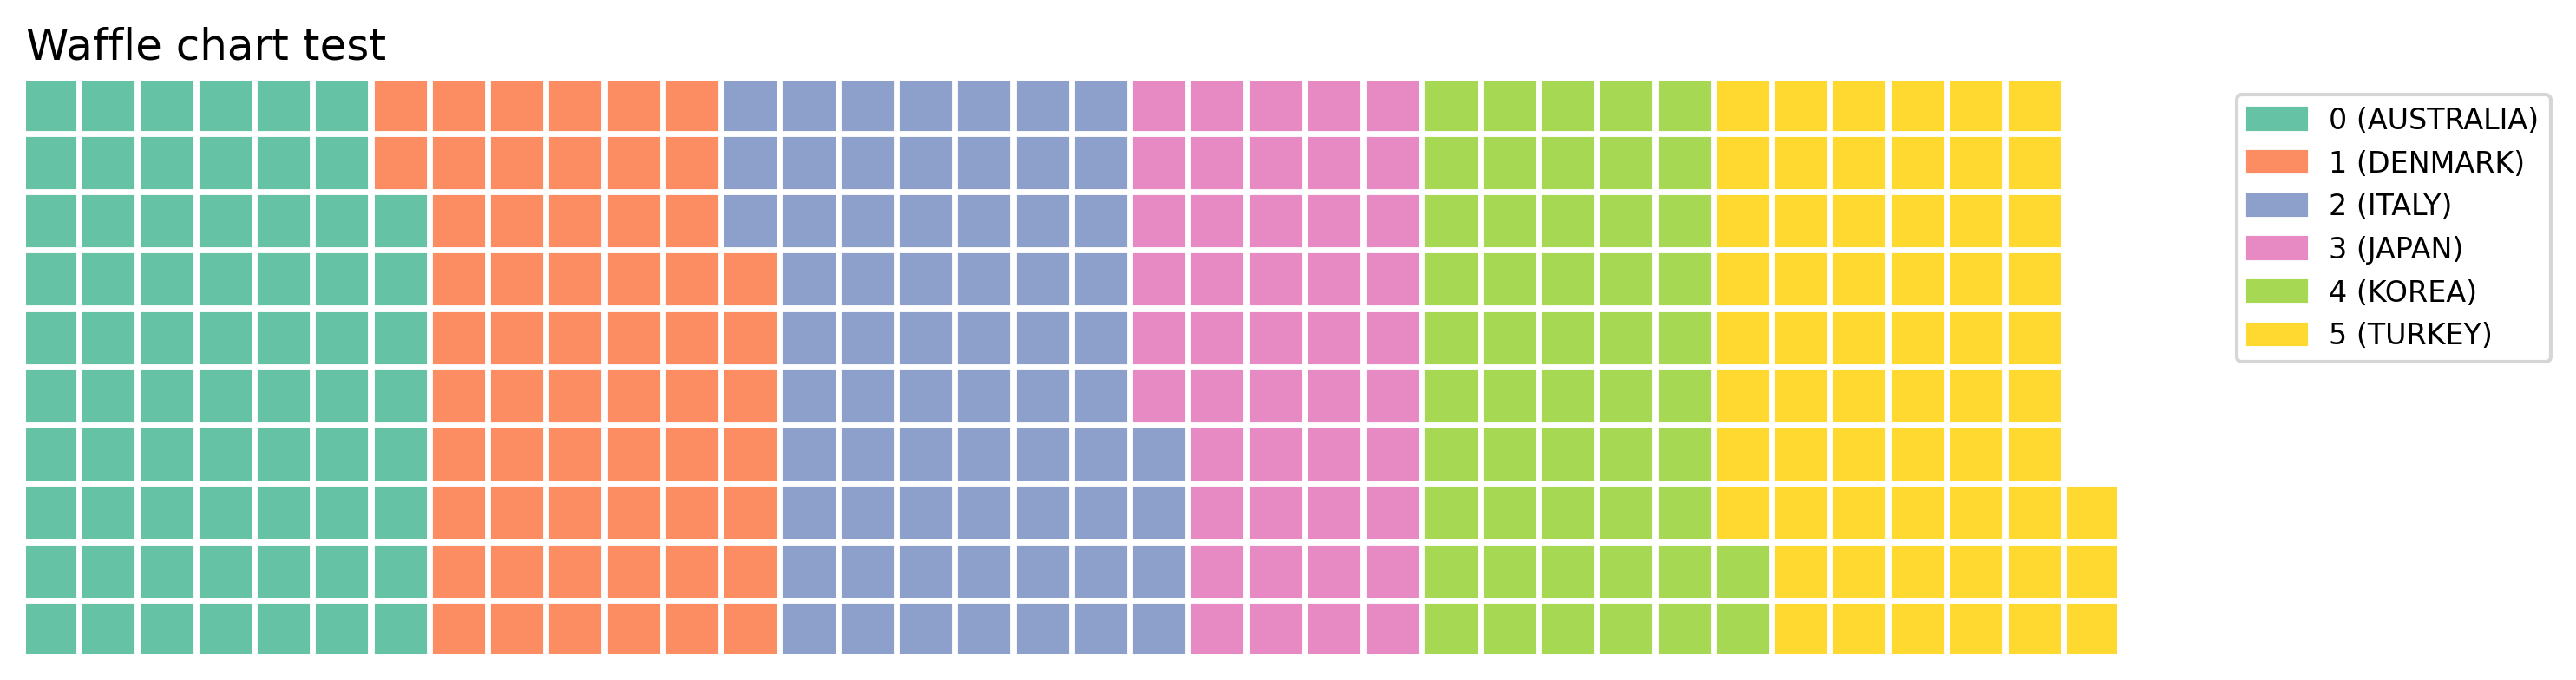

In [32]:
# 와플차트 시각화

fig = plt.figure(
    FigureClass=Waffle,
    # matplotlib의 Figure 객체를 생성할 때, Waffle을 그래프 클래스(FigureClass)로 지정함
    # 즉, 일반 플롯이 아닌 Waffle 차트를 출력하기 위한 설정임

    plots={
        111: {  # 1행 1열의 단일 subplot을 의미하는 matplotlib 인덱스
            'values': df2['height_cm_count'],
            # 각 국가별 키 ≥ 175cm 인원의 수 (조각 개수 비율을 결정함)
            # 각 값이 와플 블록의 수로 환산되어 표현됨 (예: 40명 → 40칸)

            'labels': ["{0} ({1})".format(n, v) for n, v in df2['country'].items()],
            # 각 블록 그룹(국가)에 표시될 레이블을 정의함
            # 예: “USA (42)”, “KOR (11)” 과 같이 국가명과 해당 국가의 값(=인원 수)를 함께 표시함
            # df2['country']는 인덱스 기반 시리즈이므로 .items()를 통해 (인덱스, 값) 튜플로 반복 접근함
            # 문자열 포맷: "{국가명} ({인원 수})"

            'legend': {
                'loc': 'upper left',
                # 범례를 왼쪽 위에 배치함

                'bbox_to_anchor': (1.05, 1),
                # 범례 박스를 그래프 외부 오른쪽에 위치시킴 (x=1.05, y=1 기준)

                'fontsize': 8
                # 범례 폰트 크기를 작게 설정함 (디자인 균형 고려)
            },

            'title': {
                'label': 'Waffle chart test',
                # 차트의 제목 지정

                'loc': 'left'
                # 제목 위치를 왼쪽 정렬로 설정함
            }
        }
    },

    rows=10,
    # 전체 와플 차트의 세로 방향 블록 수를 10으로 설정
    # 예: 총 블록이 100개면 10행 x 10열로 구성됨 (100% 표현 구조)

    figsize=(10, 10)
    # 전체 그래프의 크기를 10x10인치로 설정함
    # 블록 크기와 간격이 명확히 보이도록 적절한 비율을 확보함
)
